<a href="https://colab.research.google.com/github/sagunadk07/Tvisha-Your-Skincare-Partner/blob/main/SKINDATASET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [77]:
import os

In [78]:
dataset_path = "/content/drive/MyDrive/Tvisha/dataset"

In [79]:
import os

os.listdir("/content/drive/MyDrive")

['Classroom',
 '8086_Program (1).gdoc',
 '8086_Program.gdoc',
 '1.Program to display Electronics an (2).gdoc',
 '1.Program to display Electronics an (1).gdoc',
 '1.Program to display Electronics an.gdoc',
 'Untitled document (9).gdoc',
 'Untitled document (8).gdoc',
 'lab3.gdoc',
 'smart budget tracker - Bar chart 1 (1).gsheet',
 'smart budget tracker - Line chart 1.gsheet',
 'smart budget tracker - Bar chart 1.gsheet',
 'smart budget tracker.gdoc',
 '20117982.pdf',
 '20117982.gdoc',
 'Weather Station - Column chart 1.gsheet',
 'Weather Station - Line chart 1.gsheet',
 'Weather Station - Bar chart 1 (2).gsheet',
 'Weather Station - Bar chart 1 (1).gsheet',
 'Untitled drawing - Bar chart 1 (2).gsheet',
 'Untitled spreadsheet.gsheet',
 'Untitled drawing - Bar chart 1 (1).gsheet',
 'Untitled drawing - Bar chart 1.gsheet',
 'Untitled drawing.gdraw',
 'Weather Station - Bar chart 1.gsheet',
 'Untitled document (7).gdoc',
 'AI solving set ',
 'Saved from Chrome',
 'project',
 'project.zip',


In [80]:
dataset_path = "/content/drive/MyDrive/Skin Dataset"

In [81]:
os.listdir(dataset_path)

['dataset-20260709T040035Z-3-001.zip']

In [82]:
import zipfile

zip_path = "/content/drive/MyDrive/Skin Dataset/dataset-20260709T040035Z-3-001.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset successfully extracted!")

Dataset successfully extracted!


In [83]:
import os

os.listdir("/content/dataset")

['dataset']

In [84]:
import os

os.listdir("/content/dataset/dataset")

['inflammatory acne',
 'pores',
 'non inflammatory acne white heads',
 'wrinkles',
 'dark spots',
 'non inflammatory acne black heads',
 'Redness',
 'pigmentation']

In [85]:
dataset_path = "/content/dataset/dataset"

In [86]:
classes = os.listdir(dataset_path)

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    total = len(os.listdir(folder))
    print(cls, ":", total)

inflammatory acne : 607
pores : 600
non inflammatory acne white heads : 300
wrinkles : 600
dark spots : 669
non inflammatory acne black heads : 313
Redness : 600
pigmentation : 600


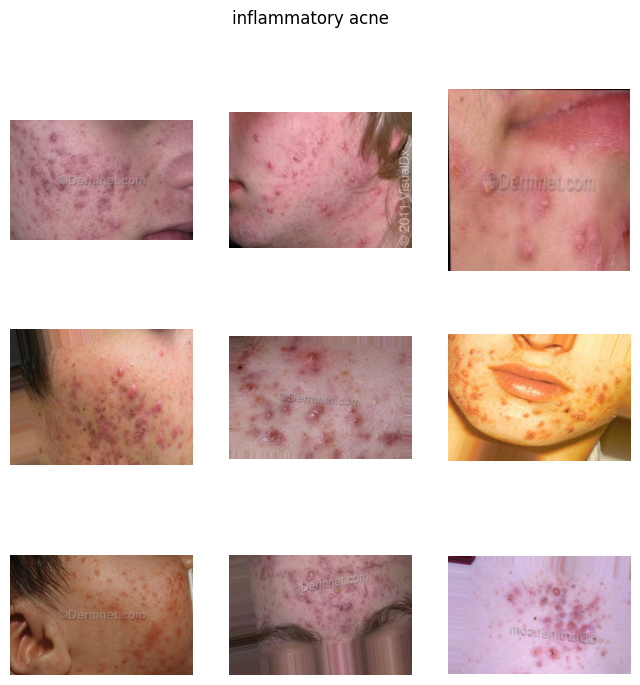

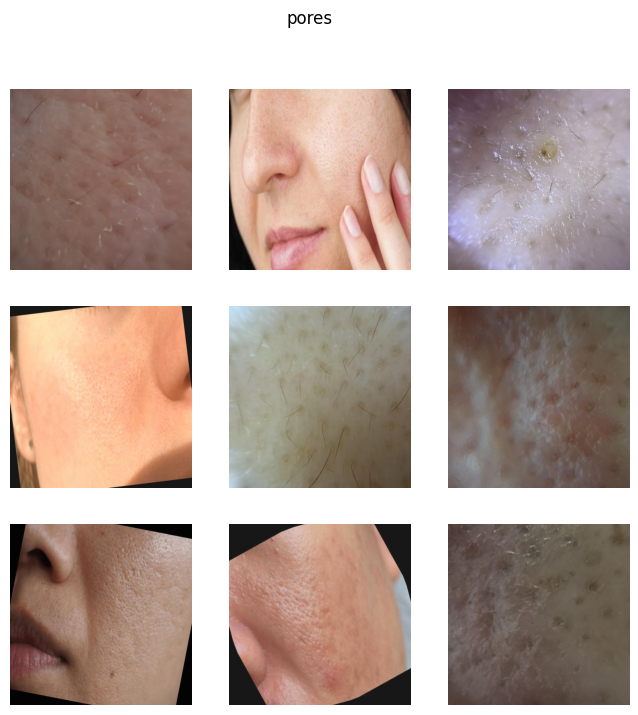

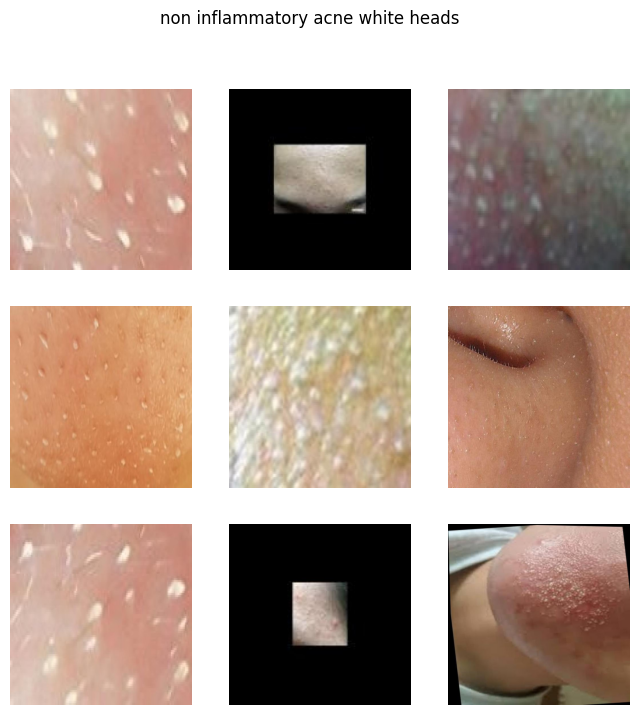

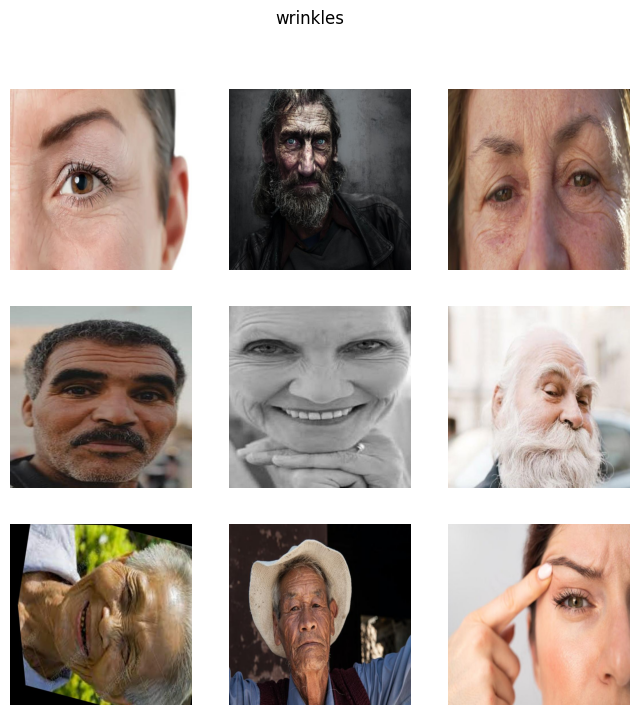

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

classes = os.listdir(dataset_path)

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    images = os.listdir(folder)

    sample_images = random.sample(images, 9)

    plt.figure(figsize=(8,8))

    for i, img_name in enumerate(sample_images):

        img = Image.open(os.path.join(folder, img_name))

        plt.subplot(3,3,i+1)

        plt.imshow(img)

        plt.axis("off")

    plt.suptitle(cls)

    plt.show()

In [ ]:
from PIL import Image
import os

classes = os.listdir(dataset_path)

total_images = 0

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        try:
            img = Image.open(img_path)

            width, height = img.size

            print(img_name, "->", width, "x", height)

            total_images += 1

        except:
            print("Cannot open:", img_name)

print("Total Images:", total_images)

In [ ]:
from PIL import Image
import os

corrupted = []

for cls in os.listdir(dataset_path):

    folder = os.path.join(dataset_path, cls)

    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)

        try:
            img = Image.open(img_path)
            img.verify()

        except:
            corrupted.append(img_path)

print("Total Corrupted Images:", len(corrupted))

In [ ]:
for img in corrupted:
    print(img)

In [ ]:
import os

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

total_images = 0
non_image_files = []

for cls in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):

        if file.lower().endswith(image_extensions):
            total_images += 1
        else:
            non_image_files.append(os.path.join(folder, file))

print("Total Image Files:", total_images)
print("Total Non-Image Files:", len(non_image_files))

In [ ]:
!pip install opencv-python


In [ ]:
import cv2
import os

blur_images = []

threshold = 100

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

for cls in os.listdir(dataset_path):

    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):

        if not file.lower().endswith(image_extensions):
            continue

        img_path = os.path.join(folder, file)

        img = cv2.imread(img_path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

        if blur_score < threshold:
            blur_images.append((img_path, blur_score))

print("Blur Images Found:", len(blur_images))

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

for i, (img_path, score) in enumerate(blur_images[:20]):

    plt.figure(figsize=(3,3))
    img = Image.open(img_path)

    plt.imshow(img)
    plt.title(f"Blur Score: {score:.2f}")
    plt.axis("off")
    plt.show()

In [ ]:
threshold = 30

In [ ]:
threshold = 30

In [ ]:
!pip install imagehash

In [ ]:
from PIL import Image
import imagehash
import os

hashes = {}
duplicates = []

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

for cls in os.listdir(dataset_path):

    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):

        if not file.lower().endswith(image_extensions):
            continue

        img_path = os.path.join(folder, file)

        try:
            img = Image.open(img_path)

            h = imagehash.average_hash(img)

            if h in hashes:
                duplicates.append((img_path, hashes[h]))
            else:
                hashes[h] = img_path

        except:
            pass

print("Total Duplicate Images:", len(duplicates))

In [ ]:
print("First 10 Duplicate Pairs:\n")

for i, (dup, original) in enumerate(duplicates[:10]):
    print(f"Duplicate {i+1}")
    print("Original :", original)
    print("Duplicate:", dup)
    print("-"*60)

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

for i, (dup, original) in enumerate(duplicates[:5]):

    fig, ax = plt.subplots(1, 2, figsize=(8,4))

    ax[0].imshow(Image.open(original))
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(Image.open(dup))
    ax[1].set_title("Duplicate")
    ax[1].axis("off")

    plt.show()

In [ ]:
from PIL import Image
import numpy as np

exact_duplicates = []

for dup, original in duplicates:

    img1 = np.array(Image.open(original))
    img2 = np.array(Image.open(dup))

    if np.array_equal(img1, img2):
        exact_duplicates.append((dup, original))

print("Exact Duplicate Images:", len(exact_duplicates))

In [ ]:
import shutil
import os

backup_folder = "/content/duplicate_backup"

os.makedirs(backup_folder, exist_ok=True)

for dup, original in exact_duplicates:
    shutil.copy(dup, backup_folder)

print("Backup Completed!")
print("Backup Folder:", backup_folder)

In [ ]:
import os

removed = 0

for dup, original in exact_duplicates:
    os.remove(dup)
    removed += 1

print("Removed Images:", removed)

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

dataset_path = "/content/dataset/dataset"

classes = os.listdir(dataset_path)

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    images = [img for img in os.listdir(folder)
              if img.lower().endswith(image_extensions)]

    sample = random.sample(images, min(30, len(images)))

    plt.figure(figsize=(15,15))

    for i, img in enumerate(sample):

        plt.subplot(5,6,i+1)

        plt.imshow(Image.open(os.path.join(folder, img)))

        plt.title(str(i+1))

        plt.axis("off")

    plt.suptitle(cls, fontsize=18)

    plt.show()

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

classes = os.listdir(dataset_path)

random.seed(42)
sample_images = {}
for cls in classes:

    folder = os.path.join(dataset_path, cls)

    images = [img for img in os.listdir(folder)
              if img.lower().endswith(image_extensions)]

    sample = random.sample(images, min(30, len(images)))
    sample_images[cls] = sample

    plt.figure(figsize=(15,15))

    for i, img in enumerate(sample):

        plt.subplot(5,6,i+1)

        plt.imshow(Image.open(os.path.join(folder, img)))
        plt.title(i+1)
        plt.axis("off")

    plt.suptitle(cls, fontsize=18)
    plt.show()

In [ ]:
import os
import shutil

removed_folder = "/content/Removed_Images"

os.makedirs(removed_folder, exist_ok=True)

print("Folder Ready")

In [ ]:
dataset_path = "/content/drive/MyDrive/Skin Dataset/dataset"

import os
print(os.path.exists(dataset_path))


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/Skin Dataset"))

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Skin Dataset/dataset-20260709T040035Z-3-001.zip"

extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(" Dataset Extracted Successfully")

In [ ]:
import os

print(os.listdir("/content/dataset"))

In [ ]:
print(os.listdir("/content/dataset/dataset"))

In [ ]:
dataset_path = "/content/dataset/dataset"

print(dataset_path)

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

classes = os.listdir(dataset_path)

random.seed(42)

sample_images = {}

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    images = [img for img in os.listdir(folder)
              if img.lower().endswith(image_extensions)]

    sample = random.sample(images, min(30, len(images)))

    sample_images[cls] = sample

    plt.figure(figsize=(15,15))

    for i, img in enumerate(sample):
        plt.subplot(5,6,i+1)
        plt.imshow(Image.open(os.path.join(folder, img)))
        plt.title(i+1)
        plt.axis("off")

    plt.suptitle(cls, fontsize=18)
    plt.show()

In [ ]:
print(sample_images.keys())

In [ ]:
selected = {
    "pores": [6,11,14,19],
    "wrinkles": [],
    "pigmentation": [23,24],
    "Redness": [5,6,7,16,21,30],
    "non inflammatory acne white heads": [28],
    "dark spots": [3,22,29,30],
    "non inflammatory acne black heads": [22],
    "inflammatory acne": []
}

for cls, nums in selected.items():
    print(f"\n===== {cls} =====")

    for n in nums:
        print(n, "->", sample_images[cls][n-1])

In [ ]:
import os
import shutil

removed_folder = "/content/Removed_Images"
os.makedirs(removed_folder, exist_ok=True)

for cls, nums in selected.items():

    class_folder = os.path.join(dataset_path, cls)

    for n in nums:

        filename = sample_images[cls][n-1]

        src = os.path.join(class_folder, filename)

        dst = os.path.join(removed_folder, filename)

        if os.path.exists(src):
            shutil.move(src, dst)
            print("Moved:", filename)

In [ ]:
print("Total removed images:", len(os.listdir(removed_folder)))

In [ ]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    total = len([
        f for f in os.listdir(folder)
        if f.lower().endswith(image_extensions)
    ])

    print(f"{cls}: {total} images")

In [ ]:
print("Total removed images:", len(os.listdir(removed_folder)))

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

classes = os.listdir(dataset_path)

random.seed(42)

sample_images = {}

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    images = [img for img in os.listdir(folder)
              if img.lower().endswith(image_extensions)]

    sample = random.sample(images, min(30, len(images)))

    sample_images[cls] = sample

    plt.figure(figsize=(15,15))

    for i, img in enumerate(sample):
        plt.subplot(5,6,i+1)
        plt.imshow(Image.open(os.path.join(folder, img)))
        plt.title(i+1)
        plt.axis("off")

    plt.suptitle(cls)
    plt.show()

In [ ]:
for cls, nums in selected.items():
    print(f"\n===== {cls} =====")

    for n in nums:
        print(n, "->", sample_images[cls][n-1])

In [ ]:
print(len(duplicates))

In [ ]:
import os
import shutil

duplicate_folder = "/content/Removed_Images/Duplicates"
os.makedirs(duplicate_folder, exist_ok=True)

moved = 0

for original, duplicate in duplicates:

    if os.path.exists(duplicate):

        filename = os.path.basename(duplicate)

        dst = os.path.join(duplicate_folder, filename)

        shutil.move(duplicate, dst)

        moved += 1

print("Total duplicate images moved:", moved)

In [ ]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    total = len([
        f for f in os.listdir(folder)
        if f.lower().endswith(image_extensions)
    ])

    print(f"{cls}: {total} images")

In [ ]:
import cv2
import os

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

blur_images = []

threshold = 30   # Blur threshold

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for img in os.listdir(folder):

        if img.lower().endswith(image_extensions):

            path = os.path.join(folder, img)

            image = cv2.imread(path)

            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            score = cv2.Laplacian(gray, cv2.CV_64F).var()

            if score < threshold:
                blur_images.append(path)

print("Blur Images:", len(blur_images))

In [ ]:
import cv2
import numpy as np
import os

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

dark_images = []

threshold = 40

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for img in os.listdir(folder):

        if img.lower().endswith(image_extensions):

            path = os.path.join(folder, img)

            image = cv2.imread(path)

            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            brightness = np.mean(gray)

            if brightness < threshold:
                dark_images.append(path)

print("Dark Images:", len(dark_images))

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

random.seed(42)

sample_dark = random.sample(dark_images, min(30, len(dark_images)))

plt.figure(figsize=(15,15))

for i, img in enumerate(sample_dark):
    plt.subplot(5,6,i+1)
    plt.imshow(Image.open(img))
    plt.title(i+1)
    plt.axis("off")

plt.show()

In [ ]:
import cv2
import numpy as np
import os

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

bright_images = []

threshold = 220   # Brightness threshold

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for img in os.listdir(folder):

        if img.lower().endswith(image_extensions):

            path = os.path.join(folder, img)

            image = cv2.imread(path)

            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            brightness = np.mean(gray)

            if brightness > threshold:
                bright_images.append(path)

print("Bright Images:", len(bright_images))

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(12,8))

for i, img in enumerate(bright_images):
    plt.subplot(2,4,i+1)
    plt.imshow(Image.open(img))
    plt.title(i+1)
    plt.axis("off")

plt.show()

In [ ]:
remove_bright = [2, 4, 5, 6]

for n in remove_bright:
    print(n, "->", bright_images[n-1])

In [ ]:
import os
import shutil

bright_folder = "/content/Removed_Images/Bright"
os.makedirs(bright_folder, exist_ok=True)

remove_bright = [2, 4, 5, 6]

for n in remove_bright:

    src = bright_images[n-1]

    filename = os.path.basename(src)

    dst = os.path.join(bright_folder, filename)

    if os.path.exists(src):
        shutil.move(src, dst)
        print("Moved:", filename)

In [ ]:
print("Bright images removed:", len(os.listdir(bright_folder)))

In [ ]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

print("Final Dataset Summary\n")

for cls in sorted(classes):
    folder = os.path.join(dataset_path, cls)

    total = len([
        f for f in os.listdir(folder)
        if f.lower().endswith(image_extensions)
    ])

    print(f"{cls}: {total} images")

In [ ]:
import shutil

source = "/content/dataset/dataset"
destination = "/content/drive/MyDrive/Cleaned_Dataset"

shutil.copytree(source, destination, dirs_exist_ok=True)

print(" Cleaned Dataset Saved to Google Drive")


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Cleaned_Dataset"

print(os.path.exists(dataset_path))


In [ ]:
classes = os.listdir(dataset_path)

print(classes)

In [ ]:
import os

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for cls in classes:
    folder = os.path.join(dataset_path, cls)

    total = len([
        f for f in os.listdir(folder)
        if f.lower().endswith(image_extensions)
    ])

    print(cls, total)